In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB



In [4]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [5]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [6]:
df__ = dt.add_pca_df(df_)

In [7]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [8]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10, event_onset=(100, 500))
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

df_tr['disturb_sum'] = df_tr['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

# Add instantaneous phase
disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 41 of 333 rows (12.31%).


In [14]:
### go from here

df_design = df_tr.copy()
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

## Subspace overlap: motor potent (MOp→bhv) vs. communication (MOp→CP)

Compute the cos² overlap between:
- **Motor potent subspace**: directions in MOp that best predict kinematics (`bhv`)
- **MOp→CP communication subspace**: directions in MOp that best predict CP activity

Both embeddings use the **2-second window post-perturbation** (bins 200–400 of `perturb_td`, which spans −2 s to +3 s around `idx_sol_on` at 10 ms/bin).


In [12]:
from tools.subspaces.utils import compute_embedding, compute_overlap_between_subspaces

RANK = 5

# perturb_td spans rel_start=-200 to rel_end=300 bins @ 10 ms/bin
# → perturbation onset sits at index 200; 2 s post-perturbation = bins 200:400
WINDOW = (200, 400)

# --- 1. Motor potent subspace: MOp → bhv (kinematics) ---
W_motor = compute_embedding(
    perturb_td,
    signal_x='MOp_rates_pca',
    signal_y='bhv',
    time_bin_window=WINDOW,
    model=subspaces.ReducedRankCommSubspace(rank=RANK),
)
print(f"W_motor shape: {W_motor.shape}")  # (n_MOp_PCs, RANK)

# --- 2. Communication subspace: MOp → CP ---
W_comm = compute_embedding(
    perturb_td,
    signal_x='MOp_rates_pca',
    signal_y='CP_rates_pca',
    time_bin_window=WINDOW,
    model=subspaces.ReducedRankCommSubspace(rank=RANK),
)
print(f"W_comm shape:  {W_comm.shape}")  # (n_MOp_PCs, RANK)

# --- 3. cos² overlap between the two subspaces ---
overlap = compute_overlap_between_subspaces(W_motor, W_comm)
print(f"\ncos² overlap (motor potent ∩ MOp→CP comm): {overlap:.4f}")


W_motor shape: (178, 5)
W_comm shape:  (178, 5)

cos² overlap (motor potent ∩ MOp→CP comm): 0.1835


In [10]:
N_PERMS = 50
rng_perm = np.random.default_rng(0)

null_overlaps = []
bhv_values = perturb_td['bhv'].values.copy()

for i in tqdm(range(N_PERMS), desc='Permutations'):
    # Shuffle bhv rows only — breaks MOp↔bhv trial alignment, 
    # preserves temporal structure within each trial
    perm_idx = rng_perm.permutation(len(bhv_values))
    td_perm = perturb_td.copy()
    td_perm['bhv'] = bhv_values[perm_idx]

    W_motor_null = compute_embedding(
        td_perm,
        signal_x='MOp_rates_pca',
        signal_y='bhv',
        time_bin_window=WINDOW,
        model=subspaces.ReducedRankCommSubspace(rank=RANK),
    )
    null_overlaps.append(compute_overlap_between_subspaces(W_motor_null, W_comm))

null_overlaps = np.array(null_overlaps)

# --- Statistics ---
p_val = np.mean(null_overlaps >= overlap)
z_score = (overlap - null_overlaps.mean()) / null_overlaps.std()
print(f"Observed overlap : {overlap:.4f}")
print(f"Null mean ± std  : {null_overlaps.mean():.4f} ± {null_overlaps.std():.4f}")
print(f"Z-score          : {z_score:.2f}")
print(f"Permutation p    : {p_val:.4f}  (n={N_PERMS})")


Permutations: 100%|██████████| 50/50 [00:09<00:00,  5.11it/s]

Observed overlap : 0.1835
Null mean ± std  : 0.0639 ± 0.0178
Z-score          : 6.72
Permutation p    : 0.0000  (n=50)


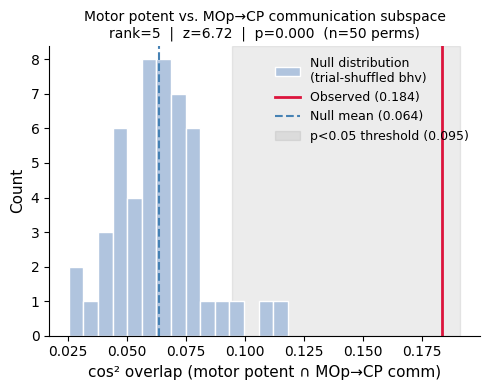

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(null_overlaps, bins=15, color='lightsteelblue', edgecolor='white',
        label='Null distribution\n(trial-shuffled bhv)', zorder=2)
ax.axvline(overlap, color='crimson', lw=2, label=f'Observed ({overlap:.3f})')
ax.axvline(null_overlaps.mean(), color='steelblue', lw=1.5, linestyle='--',
           label=f'Null mean ({null_overlaps.mean():.3f})')

# Shaded 95th percentile
p95 = np.percentile(null_overlaps, 95)
ax.axvspan(p95, ax.get_xlim()[1] if ax.get_xlim()[1] > p95 else p95 * 1.3,
           alpha=0.15, color='gray', label=f'p<0.05 threshold ({p95:.3f})')

ax.set_xlabel('cos² overlap (motor potent ∩ MOp→CP comm)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(
    f'Motor potent vs. MOp→CP communication subspace\n'
    f'rank={RANK}  |  z={z_score:.2f}  |  p={p_val:.3f}  '
    f'(n={N_PERMS} perms)',
    fontsize=10,
)
ax.legend(fontsize=9, frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [15]:
from tools.subspaces.regression import cross_val_semedo_rrr, get_opt_rank
from tools.subspaces.communication import compute_embedding_on_td

WINDOW = (0, 190)
RANK_LIST = np.arange(1, 31)

# Per-area Y truncation for rank CV
TARGET_RANKS = {'SSp': 20, 'VAL': 50, 'CP': 30}

# Auto-detect target areas, excluding MOp and GPe
AREAS = [
    c.replace('_rates_pca', '')
    for c in perturb_td_shuff.columns
    if c.endswith('_rates_pca') and not c.startswith('MOp') and c != 'GPe_rates_pca'
]
print("Target areas:", AREAS)

# --- Semedo rank optimisation on FULL (non-windowed) trial data ---
# Rank is optimised on all time bins; embeddings are later computed on WINDOW only
optimal_ranks = {}

for area in AREAS:
    target_rank = TARGET_RANKS[area]
    X_full = np.concatenate(perturb_td_shuff['MOp_rates_pca'].values)
    Y_full = np.concatenate(perturb_td_shuff[f'{area}_rates_pca'].values)[:, :target_rank]

    _, opt_rank = cross_val_semedo_rrr(
        X_full, Y_full, alpha=100, fit_rank=True, ranks=RANK_LIST
    )
    optimal_ranks[area] = int(opt_rank)
    print(f"  {area}: opt_rank = {opt_rank}  (target_rank={target_rank})")

# --- Also optimise rank for MOp → bhv (motor potent subspace) ---
X_full = np.concatenate(perturb_td_shuff['MOp_rates_pca'].values)
Y_full = np.concatenate(perturb_td_shuff['bhv'].values)[:, feature_dims]  # z-dims only

_, opt_rank_bhv = cross_val_semedo_rrr(
    X_full, Y_full, alpha=100, fit_rank=True, ranks=RANK_LIST
)
optimal_ranks['bhv'] = int(opt_rank_bhv)
print(f"  bhv (z-dims): opt_rank = {opt_rank_bhv}")
print(f"\nAll optimal ranks: {optimal_ranks}")


Target areas: ['SSp', 'VAL', 'CP']


100%|██████████| 30/30 [00:07<00:00,  4.25it/s]


  SSp: opt_rank = 5  (target_rank=20)


100%|██████████| 30/30 [00:08<00:00,  3.54it/s]


  VAL: opt_rank = 10  (target_rank=50)


100%|██████████| 30/30 [00:07<00:00,  4.22it/s]


  CP: opt_rank = 8  (target_rank=30)


100%|██████████| 30/30 [00:07<00:00,  3.97it/s]


  bhv (z-dims): opt_rank = 4

All optimal ranks: {'SSp': 5, 'VAL': 10, 'CP': 8, 'bhv': 4}


In [ ]:
N_PERMS = 20

# Pre-fetch bhv array once
bhv_values_all = perturb_td_shuff['bhv'].values.copy()

def _one_perm(seed, td, W_comm_area, rank):
    rng_ = np.random.default_rng(seed)
    perm_idx = rng_.permutation(len(td))
    td_perm = td.copy()
    td_perm['bhv'] = bhv_values_all[perm_idx]
    W_null, _ = compute_embedding_on_td(
        td_perm,
        signal_x='MOp_rates_pca',
        signal_y='bhv',
        model=subspaces.ReducedRankCommSubspace(rank=rank),
        window=WINDOW,
    )
    return compute_overlap_between_subspaces(W_null, W_comm_area)

results = {}  # area → dict with overlap, null_overlaps, z, p, opt_rank, W_motor, W_comm

for area in AREAS:
    opt_rank = optimal_ranks[area]
    print(f"\n{'='*50}\n{area}  (rank={opt_rank})")

    # Observed comm subspace: MOp → area  (windowed)
    W_comm_area, _ = compute_embedding_on_td(
        perturb_td_shuff,
        signal_x='MOp_rates_pca',
        signal_y=f'{area}_rates_pca',
        model=subspaces.ReducedRankCommSubspace(rank=opt_rank),
        window=WINDOW,
    )

    # Observed motor potent subspace: MOp → bhv  (windowed)
    W_motor_area, _ = compute_embedding_on_td(
        perturb_td_shuff,
        signal_x='MOp_rates_pca',
        signal_y='bhv',
        model=subspaces.ReducedRankCommSubspace(rank=opt_rank),
        window=WINDOW,
    )

    obs_overlap = compute_overlap_between_subspaces(W_motor_area, W_comm_area)

    # Null distribution — parallelised over permutations
    null = Parallel(n_jobs=-1, prefer='threads')(
        delayed(_one_perm)(seed, perturb_td_shuff, W_comm_area, opt_rank)
        for seed in tqdm(range(N_PERMS), desc=f'  perm {area}')
    )
    null = np.array(null)

    p  = np.mean(null >= obs_overlap)
    z  = (obs_overlap - null.mean()) / null.std()
    print(f"  observed={obs_overlap:.4f}  null={null.mean():.4f}±{null.std():.4f}  z={z:.2f}  p={p:.4f}")

    results[area] = dict(
        overlap=obs_overlap, null=null, p=p, z=z,
        opt_rank=opt_rank, W_motor=W_motor_area, W_comm=W_comm_area,
    )



SSp  (rank=5)


  perm SSp: 100%|██████████| 500/500 [02:15<00:00,  3.69it/s]


  observed=0.1248  null=0.0476±0.0130  z=5.94  p=0.0000

VAL  (rank=10)


  perm VAL: 100%|██████████| 500/500 [02:19<00:00,  3.57it/s]


  observed=0.1659  null=0.1164±0.0142  z=3.48  p=0.0000

CP  (rank=8)


  perm CP: 100%|██████████| 500/500 [02:12<00:00,  3.77it/s]


  observed=0.1790  null=0.0882±0.0135  z=6.75  p=0.0000


/tmp/ipykernel_974529/2326521146.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


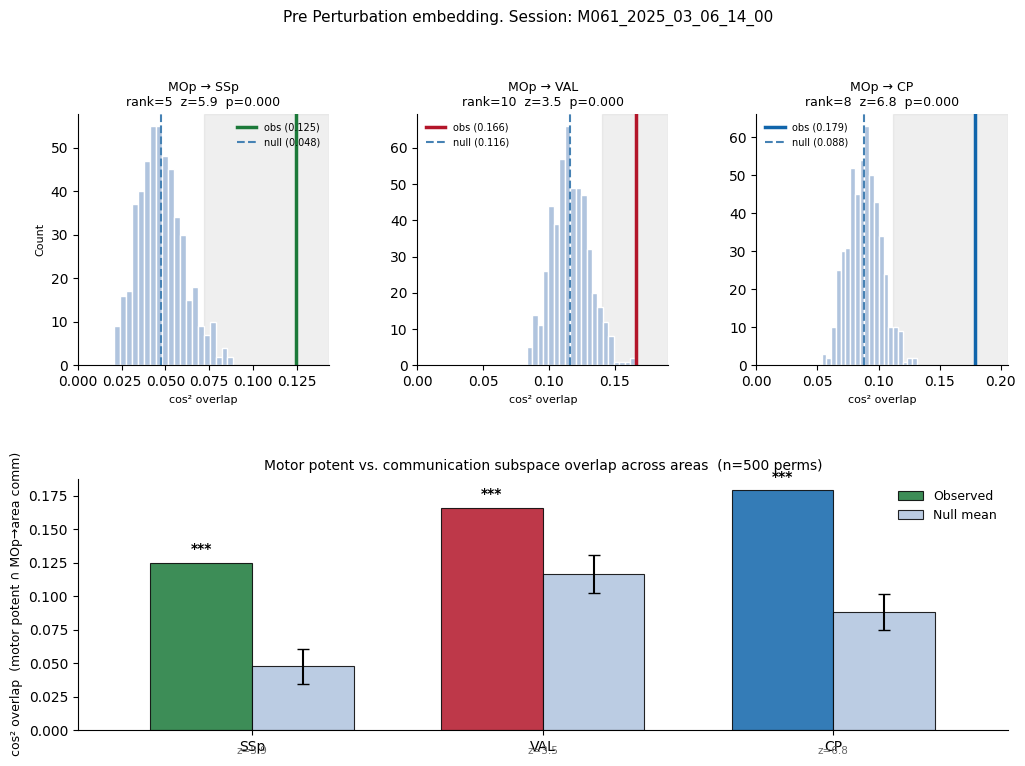

In [20]:
n_areas = len(AREAS)
area_colors = [getattr(colors, a, 'gray') for a in AREAS]

fig = plt.figure(figsize=(4 * n_areas, 8))
gs = fig.add_gridspec(2, n_areas, hspace=0.45, wspace=0.35)

# ── Row 1: null distributions per area ──────────────────────────────────────
for col, (area, c) in enumerate(zip(AREAS, area_colors)):
    r = results[area]
    ax = fig.add_subplot(gs[0, col])

    ax.hist(r['null'], bins=20, color='lightsteelblue', edgecolor='white', zorder=2)
    ax.axvline(r['overlap'], color=np.array(c) if isinstance(c, np.ndarray) else c,
               lw=2.5, label=f"obs ({r['overlap']:.3f})")
    ax.axvline(r['null'].mean(), color='steelblue', lw=1.5, ls='--',
               label=f"null ({r['null'].mean():.3f})")
    p95 = np.percentile(r['null'], 95)
    xmax = max(r['overlap'] * 1.15, p95 * 1.3)
    ax.axvspan(p95, xmax, alpha=0.12, color='gray')
    ax.set_xlim(left=0, right=xmax)
    ax.set_title(
        f"MOp → {area}\nrank={r['opt_rank']}  z={r['z']:.1f}  p={r['p']:.3f}",
        fontsize=9,
    )
    ax.set_xlabel("cos² overlap", fontsize=8)
    ax.set_ylabel("Count" if col == 0 else "", fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    sns.despine(ax=ax)

# ── Row 2: summary bar chart ─────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[1, :])

obs_vals  = [results[a]['overlap']    for a in AREAS]
null_means = [results[a]['null'].mean() for a in AREAS]
null_stds  = [results[a]['null'].std()  for a in AREAS]
z_scores   = [results[a]['z']          for a in AREAS]
p_vals     = [results[a]['p']          for a in AREAS]

x = np.arange(n_areas)
width = 0.35

bars_obs  = ax_bar.bar(x - width/2, obs_vals,  width, label='Observed',
                        color=area_colors, alpha=0.85, edgecolor='k', lw=0.8)
bars_null = ax_bar.bar(x + width/2, null_means, width, label='Null mean',
                        color='lightsteelblue', alpha=0.85, edgecolor='k', lw=0.8)
ax_bar.errorbar(x + width/2, null_means, yerr=null_stds,
                fmt='none', color='k', capsize=4, lw=1.5)

# Significance annotations
for i, (obs, p, z) in enumerate(zip(obs_vals, p_vals, z_scores)):
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    ypos = obs + 0.005
    ax_bar.text(i - width/2, ypos, sig, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax_bar.text(i, -0.012, f"z={z:.1f}", ha='center', va='top', fontsize=7.5, color='dimgray')

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(AREAS, fontsize=10)
ax_bar.set_ylabel("cos² overlap  (motor potent ∩ MOp→area comm)", fontsize=9)
ax_bar.set_title(f"Motor potent vs. communication subspace overlap across areas  (n={N_PERMS} perms)", fontsize=10)
ax_bar.legend(fontsize=9, frameon=False)
ax_bar.set_xlim(-0.6, n_areas - 0.4)
sns.despine(ax=ax_bar)

plt.suptitle(f"Pre Perturbation embedding. Session: {session}", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## Comparing it to the free locomotion period

Select intertrial data from the session (no perturbation events) and build **pseudo-trials**:
each pseudo-trial is a non-overlapping chunk of **250 bins (2.5 s)** — the same number of
bins as the analysis window used in the pre/post-perturbation conditions.

`FREE_WINDOW = (0, 250)` is applied to each chunk, so the amount of data analysed per
pseudo-trial is identical to the perturb conditions. The same `optimal_ranks` (derived from
the perturbation data) are reused for direct comparability.


In [44]:
df

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,GPe_rates_pca,CP_rates_pca,MOp_rates_pca,bhv,bhv_concat,concat_perturb_time,concat_trial_start,power,phases,disturb_score
0,M061,M061_2025_03_06_14_00,0,free,60000,0.01,0,59999,[],1.0,...,"[[-95.336426, -25.501404, 12.494308, -6.322773...","[[-46.019848, 18.388424, -13.466843, 26.988304...","[[-55.25629, 17.842503, 7.0560036, 24.368227, ...","[[-8.714492970827468, 10.93552004149664, 210.6...",None,None,None,None,None,NaN
1,M061,M061_2025_03_06_14_00,1,intertrial,500,0.01,60000,60499,[],[],...,"[[-92.539505, 24.313202, -1.8292847, -8.006729...","[[-0.97995377, 48.605236, -0.1782608, 32.43504...","[[-15.904205, 30.51979, 50.599262, 15.392239, ...","[[-7.434137154566039, 12.663991014755114, 220....",None,None,None,None,None,NaN
2,M061,M061_2025_03_06_14_00,2,trial,600,0.01,60500,61099,[],[],...,"[[-123.55969, -14.104126, 23.844345, -20.05707...","[[-25.160795, 12.757935, 28.355198, 5.681391, ...","[[-45.06693, 20.93951, 22.582027, 12.247341, -...","[[-8.308413052944957, 11.259493161075184, 217....","[[220.2292096636293, 182.07207927140195, 222.7...",700,500,"[[1.9357480389529913, 0.5140647631136392, 2.26...","[[-1.3078850375995514, -1.9341673203181395, -1...","[-0.7252674784148738, -1.00259600988252, -0.63..."
3,M061,M061_2025_03_06_14_00,3,intertrial,100,0.01,61100,61199,[],[],...,"[[-93.41878, -35.045273, 5.6697006, -30.991657...","[[-19.194908, 38.34615, 7.451927, 24.460835, 0...","[[-30.376392, 7.233118, 27.44083, 2.7175007, -...","[[-9.227197615255614, 11.519285976490409, 213....",None,None,None,None,None,NaN
4,M061,M061_2025_03_06_14_00,4,trial,600,0.01,61200,61799,[],[],...,"[[-104.2372, -7.250519, 20.189987, 20.514952, ...","[[-32.588463, -1.4829788, -1.1393127, -23.7905...","[[-40.403915, 9.873889, 30.571217, -35.881744,...","[[-6.609595859201188, 11.812341121485844, 218....","[[213.8399403716928, 181.3204914173532, 210.48...",300,100,"[[1.7717049743715485, 0.39817846564728454, 1.8...","[[-1.5152971283083425, -1.6408444645288431, -1...","[-0.1222587903184233, -0.043990419434256293, -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,M061,M061_2025_03_06_14_00,664,trial,600,0.01,358602,359201,[],[],...,"[[35.042248, -12.838394, -47.85109, -21.144974...","[[20.028221, -5.3703957, -19.513924, -6.98475,...","[[62.056877, 11.559733, -2.5872173, 57.855343,...","[[8.348886502273935, 14.30944499117332, 212.11...","[[208.8309836425153, 180.5039036044625, 205.49...",300,100,"[[1.7716258759510488, -0.274626398296108, 1.93...","[[-1.6571271778079466, 1.2593115912382307, -1....","[-0.41731300403363625, -0.3903180029838569, -0..."
665,M061,M061_2025_03_06_14_00,665,intertrial,100,0.01,359202,359301,[],[],...,"[[98.77605, 58.911163, -71.35441, 8.057543, 11...","[[38.39244, -2.337574, -2.8370323, -5.7475886,...","[[67.15305, 13.352389, -12.308008, 55.710068, ...","[[-1.0783864745592429, 13.424037526259148, 200...",None,None,None,None,None,NaN
666,M061,M061_2025_03_06_14_00,666,trial,600,0.01,359302,359901,[],[],...,"[[45.826344, 16.595688, -59.85369, -7.17305, -...","[[7.4351883, 17.590267, -16.770214, 48.882465,...","[[62.676567, 9.739907, -40.70901, 18.188068, 3...","[[-3.257798264164148, 14.341353400712029, 220....","[[200.24832952355675, 181.9139058366244, 195.0...",300,100,"[[2.110290648665403, 0.8785067940717033, 2.308...","[[1.6619750100774082, 0.2668386535445667, 1.62...","[-1.8017464034555764, -0.7968737085593116, -1...."
667,M061,M061_2025_03_06_14_00,667,intertrial,98,0.01,359902,359999,[],[],...,"[[41.428707, -50.706482, -45.45881, -59.839348...","[[34.789673, 2.5730515, -16.099216, 61.58142, ...","[[80.423805, -46.064724, -26.58525, -0.1524467...","[[-7.4482630659480575, 11.7000168265635, 217.0...",None,None,None,None,None,NaN


In [16]:
def build_pseudo_trials(td_rows, chunk_size, fields):
    """Slice each row into non-overlapping chunks of `chunk_size` bins."""
    rows = []
    for _, trial in td_rows.iterrows():
        n_bins  = trial[fields[0]].shape[0]
        n_chunks = n_bins // chunk_size
        for k in range(n_chunks):
            sl = slice(k * chunk_size, (k + 1) * chunk_size)
            chunk = {}
            valid = True
            for f in fields:
                arr = trial[f][sl]
                if np.isnan(arr).any():
                    valid = False
                    break
                chunk[f] = arr
            if valid:
                rows.append(chunk)
    return pd.DataFrame(rows)

WINDOW = (200, 450)
CHUNK_SIZE = WINDOW[1] - WINDOW[0]      # 250 bins — same as analysis window
FREE_WINDOW   = (0, CHUNK_SIZE)
fields_needed = ['MOp_rates_pca', 'bhv'] + [f'{a}_rates_pca' for a in AREAS]

# Show what trial_name values exist and which is the free row
print("trial_name counts in df:")
print(df.trial_name.value_counts().to_string())
print()

# --- Free locomotion: first (or early) rows that are not 'trial' or 'intertrial' ---
df_free_rows = df[~df.trial_name.isin(['trial', 'intertrial'])]
if len(df_free_rows) == 0:
    df_free_rows = df.iloc[[0]]
    print(f"No non-trial/intertrial rows found; using first row (trial_name='{df.iloc[0].trial_name}')")
else:
    df_free_rows = df_free_rows.iloc[[0]]

free_td = build_pseudo_trials(df_free_rows, CHUNK_SIZE, fields_needed)
print(f"Free loco source rows : {len(df_free_rows)}  →  pseudo-trials: {len(free_td)}")

# --- Intertrial (pre-perturbation / between perturbations) ---
df_it = pyal.select_trials(df, df.trial_name == 'intertrial')
intertrial_td = build_pseudo_trials(df_it, CHUNK_SIZE, fields_needed)
print(f"Intertrial source rows: {len(df_it)}  →  pseudo-trials: {len(intertrial_td)}")

# --- Balance: subsample both to the same count ---
N_PSEUDO = min(len(free_td), len(intertrial_td))
print(f"\nBalancing to {N_PSEUDO} pseudo-trials per condition")

free_td_shuff       = free_td.sample(n=N_PSEUDO, random_state=42).reset_index(drop=True)
intertrial_td_shuff = intertrial_td.sample(n=N_PSEUDO, random_state=42).reset_index(drop=True)


trial_name counts in df:
trial_name
intertrial    334
trial         333
free            2

Free loco source rows : 1  →  pseudo-trials: 240
Intertrial source rows: 334  →  pseudo-trials: 334

Balancing to 240 pseudo-trials per condition


We have some issues because the distributions are clearly very very different. 

This cleanly asks: "Is the MOp→area communication axis aligned with the canonical motor potent direction during free and intertrial running?" — without any bhv distribution confound because bhv is never touched in the per-condition estimation. The two conditions are directly comparable because they share the same `W_motor`.

The only remaining caveat is that `W_comm` estimation quality depends on how much MOp variance is locomotion-related in each condition, but that's a real biological question rather than a statistical artifact.

## Example trials

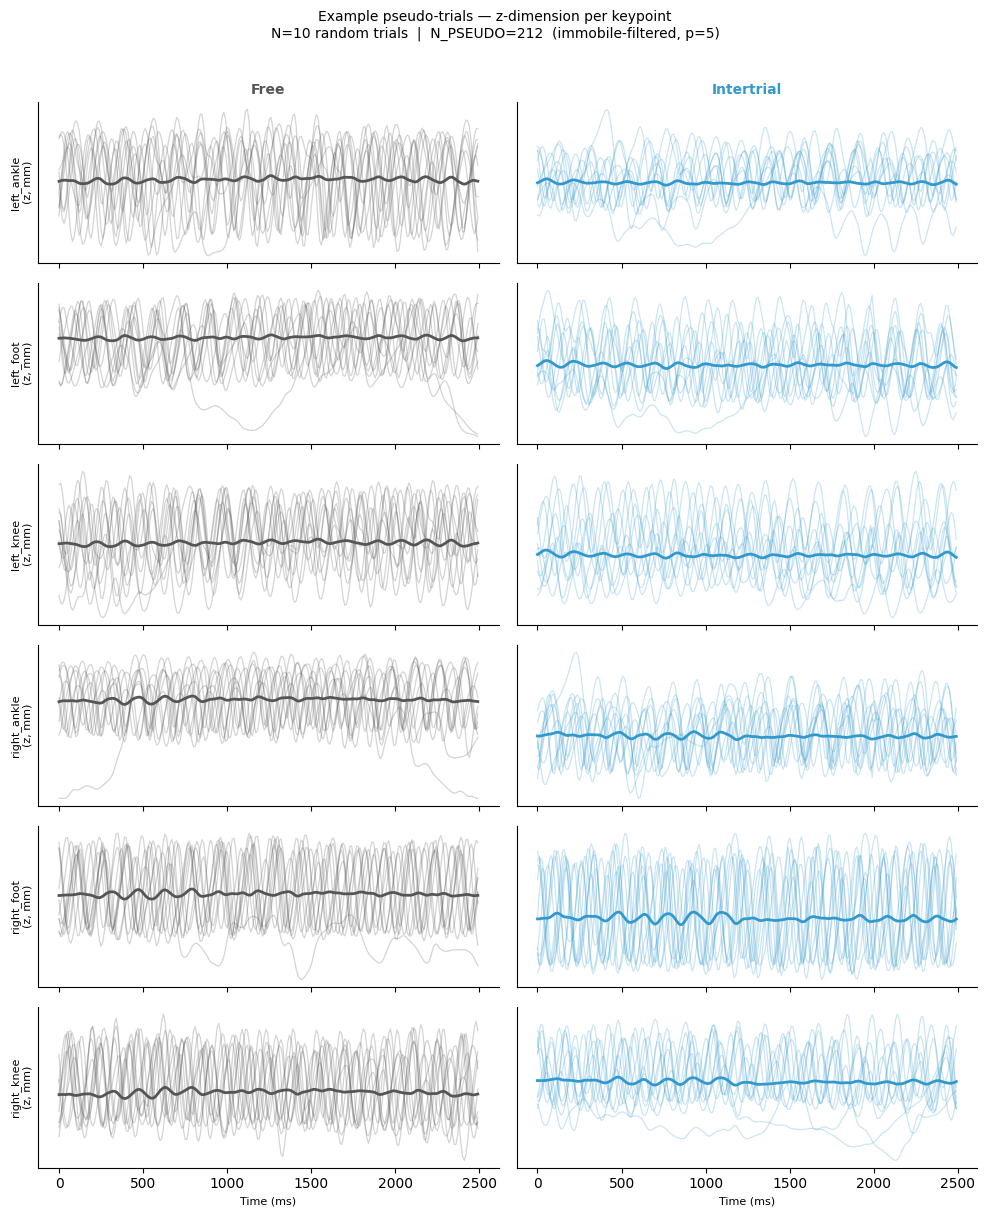

In [30]:

# ── 10 example pseudo-trials — z-dim traces for selected keypoints ────────────
# Rows = keypoints, Cols = Free | Intertrial
# Each subplot: 10 semi-transparent individual trials + bold mean

N_EX = 10
EXAMPLE_KPS = ['left_ankle', 'left_foot', 'left_knee',
                'right_ankle', 'right_foot', 'right_knee']
DIM = 2       # 0=x, 1=y, 2=z

rng_ex = np.random.default_rng(0)
t = np.arange(CHUNK_SIZE) * 10   # time in ms

n_kp = len(EXAMPLE_KPS)
fig, axes = plt.subplots(n_kp, 2, figsize=(10, n_kp * 2), sharex=True)

for row, kp in enumerate(EXAMPLE_KPS):
    col_idx = ALL_BHV_FIELDS.index(kp) * 3 + DIM   # z-dim column in bhv

    for col, (td, label, col_c) in enumerate([
        (free_td_shuff,       'Free',       '#555555'),
        (intertrial_td_shuff, 'Intertrial', '#3399cc'),
    ]):
        ax = axes[row, col]
        bhv_arr = np.stack(td['bhv'].values)   # (N, T, 36)
        traces = bhv_arr[:, :, col_idx]        # (N, T)

        ex_idx = rng_ex.choice(len(traces), size=N_EX, replace=False)
        for i in ex_idx:
            ax.plot(t, traces[i], color=col_c, alpha=0.25, lw=0.9)
        ax.plot(t, traces.mean(axis=0), color=col_c, lw=2, label='mean')

        if row == 0:
            ax.set_title(label, fontsize=10, fontweight='bold', color=col_c)
        if col == 0:
            ax.set_ylabel(f"{kp}\n(z, mm)", fontsize=8)
        ax.set_yticks([])
        sns.despine(ax=ax)

for ax in axes[-1, :]:
    ax.set_xlabel("Time (ms)", fontsize=8)

plt.suptitle(
    f"Example pseudo-trials — z-dimension per keypoint\n"
    f"N={N_EX} random trials  |  N_PSEUDO={N_PSEUDO}  (immobile-filtered, p=5)",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()


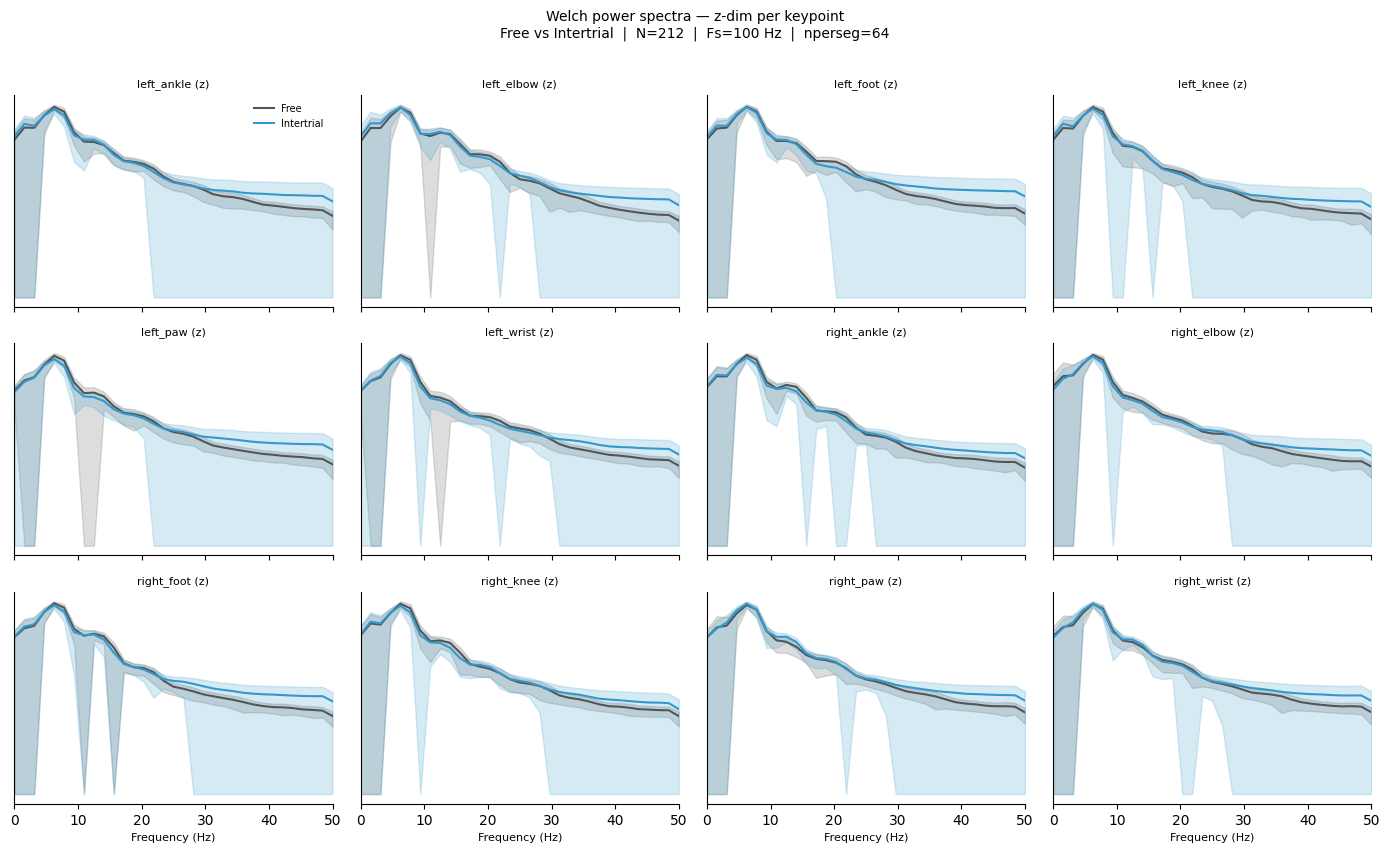

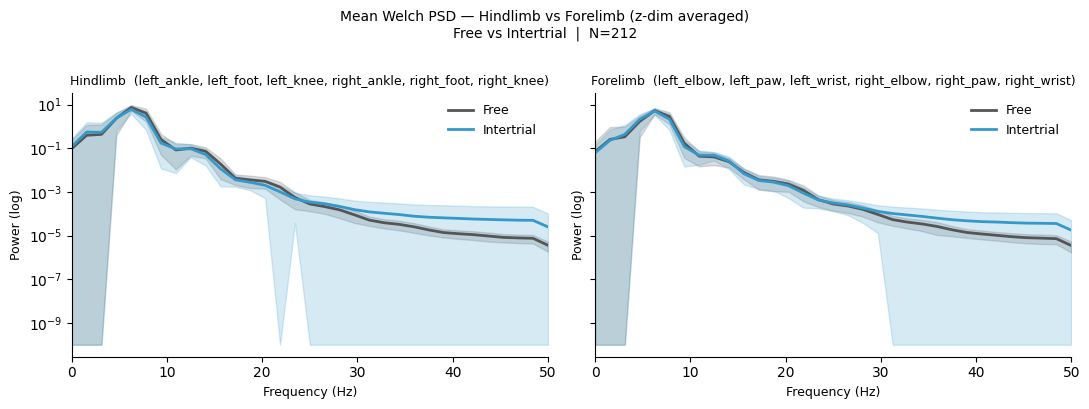

In [31]:

# ── Power spectra: Free vs Intertrial ─────────────────────────────────────────
# Welch PSD for z-dim of each keypoint; 10 ms bins → Fs = 100 Hz
# Top row: mean ± std PSD per keypoint (all 12)
# Bottom row: average PSD collapsed across hindlimb / forelimb keypoints

from scipy.signal import welch

FS = 100          # Hz (10 ms bins)
NPERSEG = 64      # ~640 ms window for Welch

bhv_free_ps = np.stack(free_td_shuff['bhv'].values)        # (N, T, 36)
bhv_it_ps   = np.stack(intertrial_td_shuff['bhv'].values)  # (N, T, 36)

cond_c = {'Free': '#555555', 'Intertrial': '#3399cc'}

# --- Per-keypoint PSD (z-dim only) ---
ncols = 4
nrows = int(np.ceil(len(ALL_BHV_FIELDS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 2.8), sharex=True)
axes = axes.flatten()

for ki, kp in enumerate(ALL_BHV_FIELDS):
    col_z = ki * 3 + 2   # z column
    ax = axes[ki]

    for arr, label in [(bhv_free_ps, 'Free'), (bhv_it_ps, 'Intertrial')]:
        psds = []
        for n in range(arr.shape[0]):
            f, pxx = welch(arr[n, :, col_z], fs=FS, nperseg=NPERSEG)
            psds.append(pxx)
        psds = np.array(psds)      # (N, freqs)
        m = psds.mean(axis=0)
        s = psds.std(axis=0)
        ax.semilogy(f, m, color=cond_c[label], lw=1.5, label=label)
        ax.fill_between(f, np.maximum(m - s, 1e-10), m + s,
                        color=cond_c[label], alpha=0.2)

    ax.set_title(f"{kp} (z)", fontsize=8)
    ax.set_xlim(0, FS / 2)
    ax.set_yticks([])
    sns.despine(ax=ax)
    if ki == 0:
        ax.legend(fontsize=7, frameon=False)

for ax in axes[len(ALL_BHV_FIELDS):]:
    ax.set_visible(False)
for ax in axes[(nrows - 1) * ncols : (nrows - 1) * ncols + ncols]:
    ax.set_xlabel("Frequency (Hz)", fontsize=8)

plt.suptitle(
    f"Welch power spectra — z-dim per keypoint\n"
    f"Free vs Intertrial  |  N={N_PSEUDO}  |  Fs={FS} Hz  |  nperseg={NPERSEG}",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()

# --- Summary: average PSD across hindlimb vs forelimb keypoints ---
hind_kps = [kp for kp in ALL_BHV_FIELDS if any(w in kp for w in HIND_KEYWORDS)]
fore_kps = [kp for kp in ALL_BHV_FIELDS if any(w in kp for w in FORE_KEYWORDS)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, group_kps, group_name in [
    (axes[0], hind_kps, 'Hindlimb'),
    (axes[1], fore_kps, 'Forelimb'),
]:
    col_zs = [ALL_BHV_FIELDS.index(kp) * 3 + 2 for kp in group_kps]

    for arr, label in [(bhv_free_ps, 'Free'), (bhv_it_ps, 'Intertrial')]:
        # Average PSD across keypoints in this group, then across trials
        group_psds = []
        for n in range(arr.shape[0]):
            trial_psds = []
            for col_z in col_zs:
                f, pxx = welch(arr[n, :, col_z], fs=FS, nperseg=NPERSEG)
                trial_psds.append(pxx)
            group_psds.append(np.mean(trial_psds, axis=0))
        group_psds = np.array(group_psds)   # (N, freqs)
        m = group_psds.mean(axis=0)
        s = group_psds.std(axis=0)
        ax.semilogy(f, m, color=cond_c[label], lw=2, label=label)
        ax.fill_between(f, np.maximum(m - s, 1e-10), m + s,
                        color=cond_c[label], alpha=0.2)

    ax.set_title(f"{group_name}  ({', '.join(group_kps)})", fontsize=9)
    ax.set_xlabel("Frequency (Hz)", fontsize=9)
    ax.set_xlim(0, FS / 2)
    ax.set_ylabel("Power (log)", fontsize=9)
    ax.legend(fontsize=9, frameon=False)
    sns.despine(ax=ax)

plt.suptitle(
    f"Mean Welch PSD — Hindlimb vs Forelimb (z-dim averaged)\n"
    f"Free vs Intertrial  |  N={N_PSEUDO}",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()


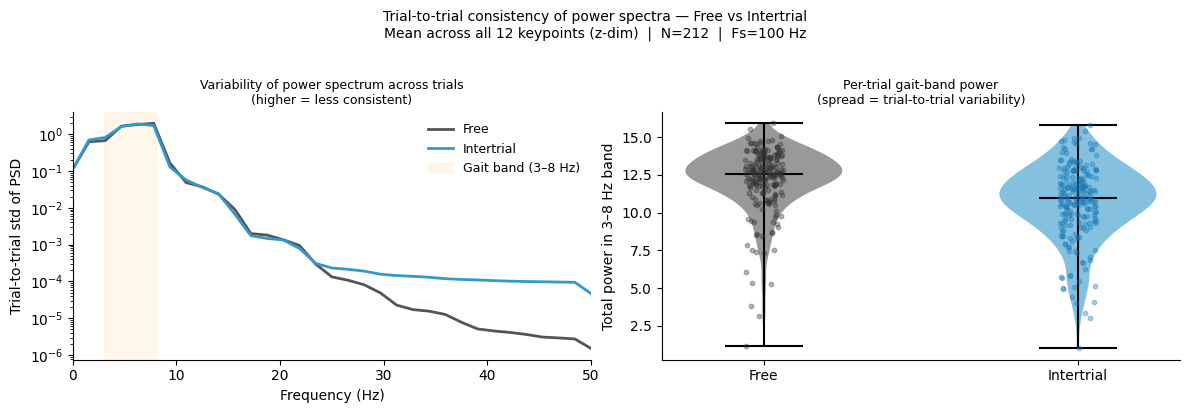

Gait-band power  Free:       mean=12.177  std=2.130  CV=0.175
Gait-band power  Intertrial: mean=10.674  std=2.521  CV=0.236


In [33]:

# ── Trial-to-trial PSD variance: Free vs Intertrial ───────────────────────────
# For each trial: compute mean PSD across all 12 keypoints (z-dim).
# Then show the *distribution* of per-trial PSDs to visualise how consistent
# each condition is across trials.

from scipy.signal import welch

GAIT_BAND = (3, 8)   # Hz — expected gait frequency range

# Compute per-trial, per-keypoint PSD; then average across keypoints
def get_trial_psds(bhv_arr, fs=FS, nperseg=NPERSEG):
    """Returns (N_trials, N_freqs) — mean PSD across all 12 z-dims."""
    n_trials, T, _ = bhv_arr.shape
    trial_psds = []
    for n in range(n_trials):
        kp_psds = []
        for ki in range(len(ALL_BHV_FIELDS)):
            col_z = ki * 3 + 2
            f_, pxx = welch(bhv_arr[n, :, col_z], fs=fs, nperseg=nperseg)
            kp_psds.append(pxx)
        trial_psds.append(np.mean(kp_psds, axis=0))
    return f_, np.array(trial_psds)   # (N, freqs)

f_ax, psds_free_tr = get_trial_psds(bhv_free_ps)
_,    psds_it_tr   = get_trial_psds(bhv_it_ps)

# Gait band mask
gait_mask = (f_ax >= GAIT_BAND[0]) & (f_ax <= GAIT_BAND[1])

# --- Fig 1: std of PSDs across trials (how variable is each freq across trials) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: trial-to-trial std of the PSD
ax = axes[0]
std_free = psds_free_tr.std(axis=0)
std_it   = psds_it_tr.std(axis=0)
ax.semilogy(f_ax, std_free, color='#555555', lw=2, label='Free')
ax.semilogy(f_ax, std_it,   color='#3399cc', lw=2, label='Intertrial')
ax.axvspan(*GAIT_BAND, alpha=0.08, color='orange', label=f'Gait band ({GAIT_BAND[0]}–{GAIT_BAND[1]} Hz)')
ax.set_xlabel('Frequency (Hz)', fontsize=10)
ax.set_ylabel('Trial-to-trial std of PSD', fontsize=10)
ax.set_title('Variability of power spectrum across trials\n(higher = less consistent)', fontsize=9)
ax.set_xlim(0, FS / 2)
ax.legend(fontsize=9, frameon=False)
sns.despine(ax=ax)

# Right: per-trial total power in gait band (violin) — spread shows consistency
ax = axes[1]
gait_power_free = psds_free_tr[:, gait_mask].sum(axis=1)
gait_power_it   = psds_it_tr[:,   gait_mask].sum(axis=1)

vp = ax.violinplot([gait_power_free, gait_power_it], positions=[0, 1],
                    showmedians=True, showextrema=True)
for body, col in zip(vp['bodies'], ['#555555', '#3399cc']):
    body.set_facecolor(col); body.set_alpha(0.6)
for part in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
    vp[part].set_color('k'); vp[part].set_linewidth(1.5)

# Overlay individual trial dots
rng_jit = np.random.default_rng(1)
for xi, (vals, col) in enumerate([(gait_power_free, '#333333'), (gait_power_it, '#1a7ab5')]):
    jitter = rng_jit.uniform(-0.06, 0.06, size=len(vals))
    ax.scatter(xi + jitter, vals, s=10, color=col, alpha=0.35, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Free', 'Intertrial'], fontsize=10)
ax.set_ylabel(f'Total power in {GAIT_BAND[0]}–{GAIT_BAND[1]} Hz band', fontsize=10)
ax.set_title('Per-trial gait-band power\n(spread = trial-to-trial variability)', fontsize=9)
sns.despine(ax=ax)

plt.suptitle(
    f"Trial-to-trial consistency of power spectra — Free vs Intertrial\n"
    f"Mean across all 12 keypoints (z-dim)  |  N={N_PSEUDO}  |  Fs={FS} Hz",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.show()

# Print summary stats
print(f"Gait-band power  Free:       mean={gait_power_free.mean():.3f}  std={gait_power_free.std():.3f}  CV={gait_power_free.std()/gait_power_free.mean():.3f}")
print(f"Gait-band power  Intertrial: mean={gait_power_it.mean():.3f}  std={gait_power_it.std():.3f}  CV={gait_power_it.std()/gait_power_it.mean():.3f}")


## Fixed-W_motor overlap: XYZ position — Free vs Intertrial

W_motor estimated from all-keypoint xyz positions (`bhv`, `optimal_ranks['bhv']=4`).  
Null = shuffle area signal per condition, W_motor held fixed.  
Grassmannian baseline = max cos² over 10 000 random rank-k subspace pairs in d=178 MOp PCs.

In [17]:

# ── Fixed-W_motor (within-condition) approach ─────────────────────────────────
# For each condition:
#   1. Estimate W_motor from that condition's MOp→bhv_signal  (fixed for the null)
#      using the rank optimised specifically for that signal  (optimal_ranks['bhv'])
#   2. Estimate W_comm from that condition's MOp→area  (observed)
#   3. Null: keep W_motor fixed, shuffle area-signal rows → re-estimate W_comm

def run_fixed_motor_within_cond(td_shuff, window, area_list, opt_ranks, n_perms, label,
                                 bhv_signal='bhv'):
    res = {}

    # --- W_motor estimated once per condition ---
    bhv_rank = opt_ranks[bhv_signal]
    W_motor_cond, _ = compute_embedding_on_td(
        td_shuff,
        signal_x='MOp_rates_pca',
        signal_y=bhv_signal,
        model=subspaces.ReducedRankCommSubspace(rank=bhv_rank),
        window=window,
    )
    print(f"[{label}] W_motor ({bhv_signal}) estimated  (rank={bhv_rank},  shape={W_motor_cond.shape})")

    for area in area_list:
        opt_rank = opt_ranks[area]

        # --- Observed W_comm ---
        W_comm_obs, _ = compute_embedding_on_td(
            td_shuff,
            signal_x='MOp_rates_pca',
            signal_y=f'{area}_rates_pca',
            model=subspaces.ReducedRankCommSubspace(rank=opt_rank),
            window=window,
        )
        obs = subspaces.compute_overlap_between_subspaces(W_motor_cond, W_comm_obs)

        # --- Null: shuffle area signal, keep W_motor fixed ---
        # Use default arg to capture area/opt_rank/W_motor_cond by value (avoid closure bug)
        area_sig = td_shuff[f'{area}_rates_pca'].values.copy()

        def _one_perm(seed, _area_sig=area_sig, _opt_rank=opt_rank, _W_motor=W_motor_cond):
            rng_ = np.random.default_rng(seed)
            td_perm = td_shuff.copy()
            td_perm[f'{area}_rates_pca'] = _area_sig[rng_.permutation(len(td_shuff))]
            W_c_null, _ = compute_embedding_on_td(
                td_perm,
                signal_x='MOp_rates_pca',
                signal_y=f'{area}_rates_pca',
                model=subspaces.ReducedRankCommSubspace(rank=_opt_rank),
                window=window,
            )
            return subspaces.compute_overlap_between_subspaces(_W_motor, W_c_null)

        null = np.array(Parallel(n_jobs=-1, prefer='threads')(
            delayed(_one_perm)(seed)
            for seed in tqdm(range(n_perms), desc=f'{label} | {area}', leave=True)
        ))

        p = np.mean(null >= obs)
        z = (obs - null.mean()) / null.std()
        print(f"[{label}] {area} (rank={opt_rank})  obs={obs:.4f}  null={null.mean():.4f}±{null.std():.4f}  z={z:.2f}  p={p:.4f}")
        res[area] = dict(overlap=obs, null=null, p=p, z=z, opt_rank=opt_rank, bhv_rank=bhv_rank)
    return res

N_PERMS = 20

results_free_fixed       = run_fixed_motor_within_cond(free_td_shuff,       FREE_WINDOW, AREAS, optimal_ranks, N_PERMS, 'Free')
results_intertrial_fixed = run_fixed_motor_within_cond(intertrial_td_shuff, FREE_WINDOW, AREAS, optimal_ranks, N_PERMS, 'Intertrial')


[Free] W_motor (bhv) estimated  (rank=4,  shape=(178, 4))


Free | SSp: 100%|██████████| 20/20 [00:00<00:00, 58133.11it/s]


[Free] SSp (rank=5)  obs=0.5083  null=0.3537±0.0153  z=10.14  p=0.0000


Free | VAL: 100%|██████████| 20/20 [00:00<00:00, 67378.38it/s]


[Free] VAL (rank=10)  obs=0.6326  null=0.4218±0.0127  z=16.65  p=0.0000


...

[Intertrial] SSp (rank=5)  obs=0.1379  null=0.0414±0.0142  z=6.81  p=0.0000


Intertrial | VAL: 100%|██████████| 20/20 [00:00<00:00, 95108.93it/s]


[Intertrial] VAL (rank=10)  obs=0.2567  null=0.0751±0.0134  z=13.57  p=0.0000


Intertrial | CP: 100%|██████████| 20/20 [00:00<00:00, 88115.63it/s]


[Intertrial] CP (rank=8)  obs=0.2064  null=0.0637±0.0144  z=9.92  p=0.0000


In [26]:

# ── Grassmannian null: baseline cos² between random rank-k subspaces in MOp ──
# d = number of MOp PCs (the full ambient space both W_motor and W_comm live in)
# For each area: draw W1 ~ Uniform(Grass(d, k_bhv)) and W2 ~ Uniform(Grass(d, k_area))
# Analytical expectation: min(k1, k2) / d

d = perturb_td_shuff['MOp_rates_pca'].iloc[0].shape[1]  # number of MOp PCs
print(f"MOp PCA dimensionality (d) = {d}")
print(f"Ranks — bhv: {optimal_ranks['bhv']}, areas: { {a: optimal_ranks[a] for a in AREAS} }")
print()

N_GRASS = 10000
rng_gr  = np.random.default_rng(42)

grassmannian_nulls = {}
for area in AREAS:
    k_bhv  = optimal_ranks['bhv']
    k_area = optimal_ranks[area]
    analytical = min(k_bhv, k_area) / d

    nulls = []
    for _ in range(N_GRASS):
        W1, _ = np.linalg.qr(rng_gr.standard_normal((d, k_bhv)))
        W2, _ = np.linalg.qr(rng_gr.standard_normal((d, k_area)))
        nulls.append(subspaces.compute_overlap_between_subspaces(W1, W2))
    nulls = np.array(nulls)
    grassmannian_nulls[area] = nulls

    print(f"  {area}  k_bhv={k_bhv}, k_area={k_area}  |  "
          f"analytical={analytical:.4f}  sim={nulls.mean():.4f}±{nulls.std():.4f}")


MOp PCA dimensionality (d) = 178
Ranks — bhv: 4, areas: {'SSp': 5, 'VAL': 10, 'CP': 8}

  SSp  k_bhv=4, k_area=5  |  analytical=0.0225  sim=0.0281±0.0086
  VAL  k_bhv=4, k_area=10  |  analytical=0.0225  sim=0.0564±0.0120
  CP  k_bhv=4, k_area=8  |  analytical=0.0225  sim=0.0448±0.0107


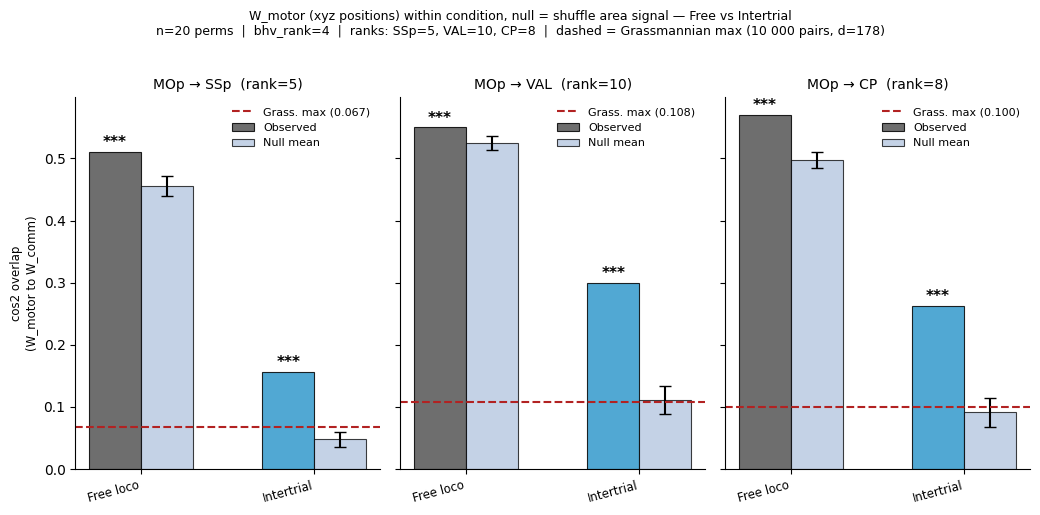

In [28]:

# --- Plot ---
CONDITIONS   = ['Free loco', 'Intertrial']
results_list = [results_free_fixed, results_intertrial_fixed]
cond_colors  = ['#555555', '#3399cc']

fig, axes = plt.subplots(1, len(AREAS), figsize=(3.5 * len(AREAS), 5), sharey=True)

for ax, area in zip(axes, AREAS):
    obs_vals = [res[area]['overlap']    for res in results_list]
    null_m   = [res[area]['null'].mean() for res in results_list]
    null_s   = [res[area]['null'].std()  for res in results_list]
    ps       = [res[area]['p']           for res in results_list]
    zs       = [res[area]['z']           for res in results_list]

    x = np.arange(len(CONDITIONS))
    w = 0.3

    ax.bar(x - w/2, obs_vals, w, color=cond_colors, alpha=0.85, edgecolor='k', lw=0.8, label='Observed')
    ax.bar(x + w/2, null_m,   w, color='lightsteelblue', alpha=0.75, edgecolor='k', lw=0.8, label='Null mean')
    ax.errorbar(x + w/2, null_m, yerr=null_s, fmt='none', color='k', capsize=4, lw=1.5)

    # Grassmannian max
    grass_max = grassmannian_nulls[area].max()
    ax.axhline(grass_max, color='firebrick', lw=1.5, ls='--',
               label=f'Grass. max ({grass_max:.3f})')

    for i, (ob, p, z) in enumerate(zip(obs_vals, ps, zs)):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        ax.text(x[i] - w/2, ob + 0.003, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(CONDITIONS, fontsize=8.5, rotation=15, ha='right')
    ax.set_title(f"MOp → {area}  (rank={optimal_ranks[area]})", fontsize=10)
    ax.set_ylabel("cos2 overlap\n(W_motor to W_comm)" if area == AREAS[0] else "", fontsize=8.5)
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)

plt.suptitle(
    f"W_motor (xyz positions) within condition, null = shuffle area signal — Free vs Intertrial\n"
    f"n={N_PERMS} perms  |  bhv_rank={optimal_ranks['bhv']}  |  "
    f"ranks: {', '.join(f'{a}={optimal_ranks[a]}' for a in AREAS)}"
    f"  |  dashed = Grassmannian max (10 000 pairs, d={perturb_td_shuff['MOp_rates_pca'].iloc[0].shape[1]})",
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.show()


# Try using position and velocities to see if distributions are more similar

In [38]:
target_lag_dict = {
    'MOp': {
        'bhv': 1,
        'MOp': None,
        'SSp': None,
        'CP': -1,
        'VAL': -3
    }}

In [ ]:

# ── Fixed-W_motor: ALL-keypoint velocity (finite-difference xyz) ──────────────
# Same approach as xyz-position analysis but W_motor is estimated from the
# velocity of all 12 keypoints (all 3 dims → 36 velocity dims per time bin).
# Velocity reduces T by 1 → use VEL_WINDOW = (0, CHUNK_SIZE-1).

ALL_VEL_WINDOW = (0, CHUNK_SIZE - 1)

# --- Compute all-keypoint velocity and attach to pseudo-trial tables ---
for td in [free_td_shuff, intertrial_td_shuff]:
    td['bhv_vel'] = [np.diff(row, axis=0) for row in td['bhv'].values]  # (T-1, 36)

# --- Use the same rank as xyz-position bhv (rank=4) to avoid rank-1 degeneracy ---
optimal_ranks['bhv_vel'] = optimal_ranks['bhv']   # reuse rank optimised for xyz positions
print(f"bhv_vel rank set to optimal_ranks['bhv'] = {optimal_ranks['bhv_vel']}")
print(f"Updated optimal_ranks: {optimal_ranks}")

# --- Run fixed-W_motor overlap analysis ---
N_PERMS_VEL = 20

results_free_vel       = run_fixed_motor_within_cond(
    free_td_shuff,       ALL_VEL_WINDOW, AREAS, optimal_ranks, N_PERMS_VEL, 'Free',
    bhv_signal='bhv_vel')
results_intertrial_vel = run_fixed_motor_within_cond(
    intertrial_td_shuff, ALL_VEL_WINDOW, AREAS, optimal_ranks, N_PERMS_VEL, 'Intertrial',
    bhv_signal='bhv_vel')

# --- Grassmannian null for bhv_vel ranks ---
d_vel = free_td_shuff['MOp_rates_pca'].iloc[0].shape[1]
rng_gr_vel = np.random.default_rng(0)
grass_vel = {}
for area in AREAS:
    k1, k2 = optimal_ranks['bhv_vel'], optimal_ranks[area]
    nulls = []
    for _ in range(10_000):
        W1, _ = np.linalg.qr(rng_gr_vel.standard_normal((d_vel, k1)))
        W2, _ = np.linalg.qr(rng_gr_vel.standard_normal((d_vel, k2)))
        nulls.append(subspaces.compute_overlap_between_subspaces(W1, W2))
    grass_vel[area] = max(nulls)
    print(f"  {area}  k_bhv_vel={k1}, k_area={k2}  grass_max={grass_vel[area]:.4f}")

# --- Plot ---
CONDITIONS_VEL   = ['Free loco', 'Intertrial']
results_list_vel = [results_free_vel, results_intertrial_vel]
cond_colors_vel  = ['#555555', '#3399cc']

fig, axes = plt.subplots(1, len(AREAS), figsize=(3.5 * len(AREAS), 5), sharey=True)

for ax, area in zip(axes, AREAS):
    obs_vals = [res[area]['overlap']    for res in results_list_vel]
    null_m   = [res[area]['null'].mean() for res in results_list_vel]
    null_s   = [res[area]['null'].std()  for res in results_list_vel]
    ps       = [res[area]['p']           for res in results_list_vel]
    zs       = [res[area]['z']           for res in results_list_vel]

    x = np.arange(len(CONDITIONS_VEL))
    w = 0.3

    ax.bar(x - w/2, obs_vals, w, color=cond_colors_vel, alpha=0.85, edgecolor='k', lw=0.8, label='Observed')
    ax.bar(x + w/2, null_m,   w, color='lightsteelblue', alpha=0.75, edgecolor='k', lw=0.8, label='Null mean')
    ax.errorbar(x + w/2, null_m, yerr=null_s, fmt='none', color='k', capsize=4, lw=1.5)

    ax.axhline(grass_vel[area], color='firebrick', lw=1.5, ls='--',
               label=f'Grass. max ({grass_vel[area]:.3f})')

    for i, (ob, p, z) in enumerate(zip(obs_vals, ps, zs)):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        ax.text(x[i] - w/2, ob + 0.003, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(CONDITIONS_VEL, fontsize=8.5, rotation=15, ha='right')
    ax.set_title(f"MOp → {area}  (rank={optimal_ranks[area]})", fontsize=10)
    ax.set_ylabel("cos² overlap\n(W_motor to W_comm)" if area == AREAS[0] else "", fontsize=8.5)
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)

plt.suptitle(
    f"W_motor from ALL-keypoint velocity (36 dims) — Free vs Intertrial\n"
    f"n={N_PERMS_VEL} perms  |  bhv_vel_rank={optimal_ranks['bhv_vel']}  |  "
    f"ranks: {', '.join(f'{a}={optimal_ranks[a]}' for a in AREAS)}"
    f"  |  dashed = Grassmannian max (10 000 pairs, d={d_vel})",
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.show()


In [29]:

# ── Fixed-W_motor: XYZ position + velocity + joint angles (80 dims) ───────────
# bhv_ext[t] = [position(t+1), velocity(t→t+1), angles(t+1)]
#            = 36 xyz + 36 vel + 8 angles → T-1 bins × 80 dims
#
# Joint angle fields are separate scalar columns in df (not part of bhv).
# Strategy: rebuild pseudo-trials including angle fields from same source,
# filter with same L2-norm speed metric → thresh_imm, balance to N_EXT.

ANGLE_FIELDS = [
    'left_ankle_angle', 'left_elbow_angle', 'left_knee_angle', 'left_wrist_angle',
    'right_ankle_angle', 'right_elbow_angle', 'right_knee_angle', 'right_wrist_angle',
]
ALL_VEL_WINDOW = (0, CHUNK_SIZE - 1)
EXT_WINDOW = ALL_VEL_WINDOW   # (0, CHUNK_SIZE-1)

# --- Rebuild pseudo-trial tables with angle columns included ---
fields_with_angles = fields_needed + ANGLE_FIELDS

free_td_ext_raw       = build_pseudo_trials(df_free_rows, CHUNK_SIZE, fields_with_angles)
intertrial_td_ext_raw = build_pseudo_trials(df_it,        CHUNK_SIZE, fields_with_angles)
print(f"Free pseudo-trials (raw): {len(free_td_ext_raw)}")
print(f"Intertrial pseudo-trials (raw): {len(intertrial_td_ext_raw)}")

# --- Immobile filter: same metric as original (mean L2 norm of z-dim velocity) ---
z_cols = np.arange(2, len(ALL_BHV_FIELDS) * 3, 3)   # z-dim indices in bhv

def trial_mean_speed(td_row):
    vel_z = np.diff(td_row['bhv'][:, z_cols], axis=0)  # (T-1, 12)
    return np.mean(np.linalg.norm(vel_z, axis=1))

sf_ext = np.array([trial_mean_speed(r) for _, r in free_td_ext_raw.iterrows()])
si_ext = np.array([trial_mean_speed(r) for _, r in intertrial_td_ext_raw.iterrows()])

# Compute immobility threshold: p=5 percentile of combined speed distribution
thresh_imm = np.percentile(np.concatenate([sf_ext, si_ext]), 5)
print(f"Immobility threshold (p=5): {thresh_imm:.3f}")

free_td_ext       = free_td_ext_raw[sf_ext >= thresh_imm].reset_index(drop=True)
intertrial_td_ext = intertrial_td_ext_raw[si_ext >= thresh_imm].reset_index(drop=True)
print(f"After immobile filter (thresh={thresh_imm:.3f}): Free={len(free_td_ext)}, IT={len(intertrial_td_ext)}")

N_EXT = min(len(free_td_ext), len(intertrial_td_ext), N_PSEUDO)
print(f"Balancing to N={N_EXT} pseudo-trials")

free_td_ext_shuff       = free_td_ext.sample(n=N_EXT, random_state=42).reset_index(drop=True)
intertrial_td_ext_shuff = intertrial_td_ext.sample(n=N_EXT, random_state=42).reset_index(drop=True)

# --- Build bhv_ext: position + velocity + angles → (T-1, 80) ---
def make_bhv_ext(td_row):
    pos = td_row['bhv']                                        # (T, 36)
    vel = np.diff(pos, axis=0)                                 # (T-1, 36)
    ang = np.column_stack([td_row[f][1:] for f in ANGLE_FIELDS])  # (T-1, 8)
    return np.concatenate([pos[1:, :], vel, ang], axis=1)      # (T-1, 80)

for td in [free_td_ext_shuff, intertrial_td_ext_shuff]:
    td['bhv_ext'] = [make_bhv_ext(row) for _, row in td.iterrows()]

# --- Build bhv_ext for perturb_td_shuff (for rank CV) ---
bhv_ext_perturb = []
mop_ext_perturb = []
for _, row in perturb_td_shuff.iterrows():
    pos = row['bhv']
    vel = np.diff(pos, axis=0)
    ang = np.column_stack([row[f][1:] for f in ANGLE_FIELDS])
    bhv_ext_perturb.append(np.concatenate([pos[1:, :], vel, ang], axis=1))
    mop_ext_perturb.append(row['MOp_rates_pca'][1:, :])

X_full_ext = np.concatenate(mop_ext_perturb)
Y_full_ext = np.concatenate(bhv_ext_perturb)
print(f"bhv_ext dims: {Y_full_ext.shape[1]}  (expected 80)")

_, opt_rank_ext = cross_val_semedo_rrr(
    X_full_ext, Y_full_ext, alpha=100, fit_rank=True, ranks=RANK_LIST
)
optimal_ranks['bhv_ext'] = int(opt_rank_ext)
print(f"Optimal rank for MOp → bhv_ext (pos+vel+angles): {opt_rank_ext}")
print(f"All optimal_ranks: {optimal_ranks}")

# --- Run fixed-W_motor overlap analysis ---
N_PERMS_EXT = 1000

results_free_ext       = run_fixed_motor_within_cond(
    free_td_ext_shuff,       EXT_WINDOW, AREAS, optimal_ranks, N_PERMS_EXT, 'Free',
    bhv_signal='bhv_ext')
results_intertrial_ext = run_fixed_motor_within_cond(
    intertrial_td_ext_shuff, EXT_WINDOW, AREAS, optimal_ranks, N_PERMS_EXT, 'Intertrial',
    bhv_signal='bhv_ext')

# --- Grassmannian null ---
d_ext      = free_td_ext_shuff['MOp_rates_pca'].iloc[0].shape[1]
rng_gr_ext = np.random.default_rng(0)
grass_ext  = {}
for area in AREAS:
    k1, k2 = optimal_ranks['bhv_ext'], optimal_ranks[area]
    nulls = []
    for _ in range(10_000):
        W1_, _ = np.linalg.qr(rng_gr_ext.standard_normal((d_ext, k1)))
        W2_, _ = np.linalg.qr(rng_gr_ext.standard_normal((d_ext, k2)))
        nulls.append(subspaces.compute_overlap_between_subspaces(W1_, W2_))
    grass_ext[area] = max(nulls)
    print(f"  {area}  k_bhv_ext={k1}, k_area={k2}  grass_max={grass_ext[area]:.4f}")


Free pseudo-trials (raw): 240
Intertrial pseudo-trials (raw): 334
Immobility threshold (p=5): 1.210
After immobile filter (thresh=1.210): Free=218, IT=327
Balancing to N=218 pseudo-trials
bhv_ext dims: 80  (expected 80)
































































100%|██████████| 30/30 [00:15<00:00,  1.96it/s]


Optimal rank for MOp → bhv_ext (pos+vel+angles): 8
All optimal_ranks: {'SSp': 5, 'VAL': 10, 'CP': 8, 'bhv': 4, 'bhv_ext': 8}
[Free] W_motor (bhv_ext) estimated  (rank=8,  shape=(178, 8))






































































































































Free | SSp: 100%|██████████| 1000/1000 [06:44<00:00,  2.47it/s]


[Free] SSp (rank=5)  obs=0.5661  null=0.5929±0.0226  z=-1.19  p=0.8920


...

[Intertrial] SSp (rank=5)  obs=0.2046  null=0.0775±0.0159  z=7.99  p=0.0000


Intertrial | VAL: 100%|██████████| 1000/1000 [06:42<00:00,  2.48it/s]


[Intertrial] VAL (rank=10)  obs=0.2299  null=0.1082±0.0129  z=9.46  p=0.0000


Intertrial | CP: 100%|██████████| 1000/1000 [07:00<00:00,  2.38it/s]


[Intertrial] CP (rank=8)  obs=0.2006  null=0.0832±0.0127  z=9.22  p=0.0000
  SSp  k_bhv_ext=8, k_area=5  grass_max=0.0965
  VAL  k_bhv_ext=8, k_area=10  grass_max=0.0925
  CP  k_bhv_ext=8, k_area=8  grass_max=0.0784


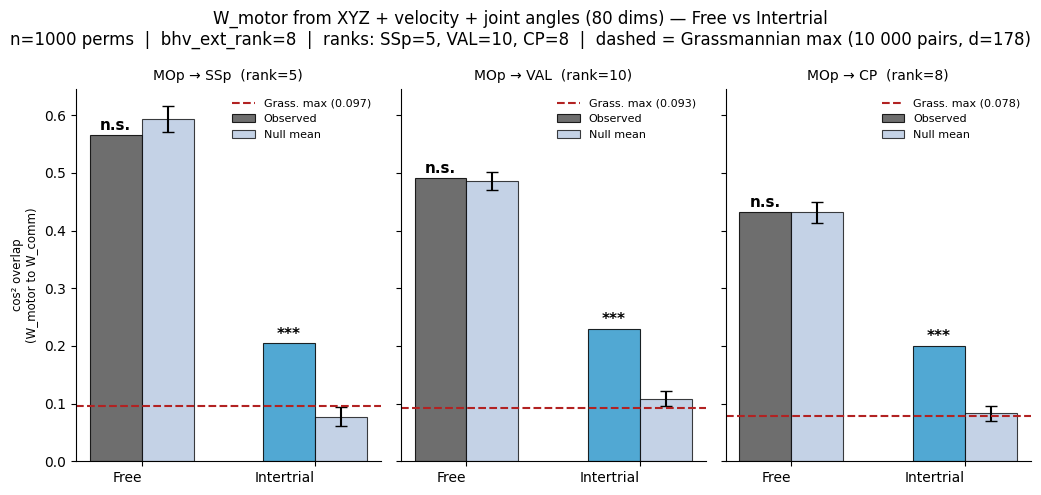

In [34]:

# --- Plot ---
fig, axes = plt.subplots(1, len(AREAS), figsize=(3.5 * len(AREAS), 5), sharey=True)
cond_colors_ext = ['#555555', '#3399cc']

for ax, area in zip(axes, AREAS):
    obs_vals = [res[area]['overlap']     for res in [results_free_ext, results_intertrial_ext]]
    null_m   = [res[area]['null'].mean() for res in [results_free_ext, results_intertrial_ext]]
    null_s   = [res[area]['null'].std()  for res in [results_free_ext, results_intertrial_ext]]
    ps       = [res[area]['p']           for res in [results_free_ext, results_intertrial_ext]]
    zs       = [res[area]['z']           for res in [results_free_ext, results_intertrial_ext]]

    x = np.arange(2)
    w = 0.3

    ax.bar(x - w/2, obs_vals, w, color=cond_colors_ext, alpha=0.85, edgecolor='k', lw=0.8, label='Observed')
    ax.bar(x + w/2, null_m,   w, color='lightsteelblue',  alpha=0.75, edgecolor='k', lw=0.8, label='Null mean')
    ax.errorbar(x + w/2, null_m, yerr=null_s, fmt='none', color='k', capsize=4, lw=1.5)

    ax.axhline(grass_ext[area], color='firebrick', lw=1.5, ls='--',
               label=f'Grass. max ({grass_ext[area]:.3f})')

    for i, (ob, p, z) in enumerate(zip(obs_vals, ps, zs)):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        ax.text(x[i] - w/2, ob + 0.003, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(['Free', 'Intertrial'], fontsize=None, rotation=0, ha='right')
    ax.set_title(f"MOp → {area}  (rank={optimal_ranks[area]})", fontsize=10)
    ax.set_ylabel("cos² overlap\n(W_motor to W_comm)" if area == AREAS[0] else "", fontsize=8.5)
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)

plt.suptitle(
    f"W_motor from XYZ + velocity + joint angles (80 dims) — Free vs Intertrial\n"
    f"n={N_PERMS_EXT} perms  |  bhv_ext_rank={optimal_ranks['bhv_ext']}  |  "
    f"ranks: {', '.join(f'{a}={optimal_ranks[a]}' for a in AREAS)}"
    f"  |  dashed = Grassmannian max (10 000 pairs, d={d_ext})",
    # fontsize=9, y=1.02,
)
plt.tight_layout()
plt.show()